# Comparison
- We have different measures for each sigma:
    - trajectory-based escape times (per point)
    - trajectory-based regime lifetimes (per "visit")
    - expected mean first passage time/escape time from TO (per point)
    - escape rate 1-lambda_max (one per TO/trajectory)
- in addition, we have different regime definitions
- in addition, we have different trajectory lengths/densities because of diffusion maps upper limit

In order to compare the different measures as well as our results to Josh's results, the following steps should be taken:

1. Calculate trajectories for sigma linearly and densely spaced between 0 and 0.05
2. Reproduce Josh's results for different trajectory lengths/step sizes
    - Note the sigma, at which stochastic inertia is apparent depending on the density

**Now switch to diffusion maps**

3. Calculate regime lifetimes for 
    - regimes defined at sigma=0
    - regimes defined at sigma=epsilon
    - Compare both to the results gathered above; especially, varying the trajectory length/density
4. Using the TO directly, calculate
    - expected mean-first passage time and compare with trajectory-based escape times with the same regime definition and trajectory density
    - escape rate 


## 1. Calculate Trajectories
**DONE**
- see in particular compandrun.sh and the respective files int cdv_model/data

## 2. Reproduce Josh's Results


In [2]:
import numpy as np
import cdv_utils
import matplotlib.pyplot as plt
import importlib
from scipy import sparse
importlib.reload(cdv_utils)

<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [3]:
import pickle
from cdv_utils import (
    load_d, plot_lifetime_distributions_lines, diffusion_maps_matrix,
    compute_clusters_from_TO, classify_new_trajectory, calculate_escape_times,
    expected_escape_times_from_TO, add_scaled_top_axis)
fixed = np.array([
    [0.7285286,   0.15657308, -0.36810966, -0.32854071, -0.08004622, 0.34314342],
    [0.94484848, 0.10714876, -0.00858286, -0.71094887, -0.17206714, 0.03996197]
])

In [6]:
# USES HUNGARIAN ALGORITHM

import os
import glob
import re
import pickle
import numpy as np
from collections import defaultdict
from scipy.optimize import linear_sum_assignment


def collect_escape_results(data_dir="./cdv_model/data", pattern="*_results.pkl"):
    """
    Collect escape lifetime data from pickle files into a nested dict:
        escape_results[regime][sigma] = list_of_lifetimes

    Relabels regimes sequentially:
      - Lowest sigma: keep original labels
      - Each subsequent sigma: relabel states to minimize total distance
        to the centers of the previous sigma (Hungarian algorithm).
    """

    # find files
    file_paths = sorted(glob.glob(os.path.join(data_dir, pattern)))

    # parse sigma values from filenames
    sigma_re = re.compile(r"sigma([0-9p\.]+)_results.*\.pkl$")
    files = []
    for fp in file_paths:
        m = sigma_re.search(os.path.basename(fp))
        if m:
            sigma_str = m.group(1).replace("p", ".")
            sigma_val = float(sigma_str)
            files.append((sigma_val, fp))
    files.sort(key=lambda x: x[0])

    # load all results
    data_all = []
    for sigma, fp in files:
        with open(fp, "rb") as f:
            d = pickle.load(f)
        data_all.append((sigma, d))

    escape_results = defaultdict(lambda: defaultdict(list))

    # start with first sigma (labels unchanged)
    prev_centers = data_all[0][1]["state_centers"]
    for r, lifetimes in data_all[0][1]["escape_times"].items():
        escape_results[r][data_all[0][0]].extend(lifetimes)

    # relabel subsequent sigmas
    for sigma, d in data_all[1:]:
        centers = d["state_centers"]
        esc = d["escape_times"]

        # compute distance matrix between centers of prev and current
        dist_matrix = np.sqrt(((
            prev_centers[:, None, :] - centers[None, :, :])**2).sum(axis=2))

        # Hungarian algorithm: minimize total distance
        row_ind, col_ind = linear_sum_assignment(dist_matrix)

        # mapping: old regime -> new consistent regime
        mapping = {col + 1: row + 1 for row, col in zip(row_ind, col_ind)}

        # relabel escape times
        for old_regime, lifetimes in esc.items():
            new_regime = mapping[old_regime]
            escape_results[new_regime][sigma].extend(lifetimes)

        # update reference centers with reordered centers
        prev_centers = centers[col_ind]        # break

    return escape_results

In [67]:
# USES x1 MEANS TO RELABEL REGIMES

import os
import glob
import re
import pickle
import numpy as np
from collections import defaultdict


def collect_escape_results(data_dir="./cdv_model/data", pattern="*_results.pkl"):
    """
    Collect escape lifetime data from pickle files into a nested dict:
        escape_results[regime][sigma] = list_of_lifetimes

    Regime indices are reassigned independently for each sigma
    by increasing magnitude of the mean_x1_by_regime values:
        1 = lowest mean_x1
        2 = middle mean_x1
        3 = highest mean_x1
    """

    # find files
    file_paths = sorted(glob.glob(os.path.join(data_dir, pattern)))

    # parse sigma values from filenames
    sigma_re = re.compile(r"sigma([0-9p\.]+)_results.*\.pkl$")
    files = []
    for fp in file_paths:
        m = sigma_re.search(os.path.basename(fp))
        if m:
            sigma_str = m.group(1).replace("p", ".")
            sigma_val = float(sigma_str)
            files.append((sigma_val, fp))
    files.sort(key=lambda x: x[0])

    # load all results
    data_all = []
    for sigma, fp in files:
        with open(fp, "rb") as f:
            d = pickle.load(f)
        data_all.append((sigma, d))

    escape_results = defaultdict(lambda: defaultdict(list))

    # relabel regimes for each sigma independently
    for sigma, d in data_all:
        esc = d["escape_times"]

        # use mean_x1_by_regime if available
        mean_x1 = d.get("mean_x1_by_regime", None)
        if mean_x1 is None:
            raise KeyError(
                f"'mean_x1_by_regime' missing in file for sigma={sigma}")

        # sort regimes by mean x1 (ascending)
        items = sorted(mean_x1.items(), key=lambda kv: kv[1])
        mapping = {old_regime: new_regime + 1 for new_regime,
                   (old_regime, _) in enumerate(items)}

        # apply new labels
        for old_regime, lifetimes in esc.items():
            new_regime = mapping[old_regime]
            escape_results[new_regime][sigma].extend(lifetimes)

    return escape_results

### For the full trajectory

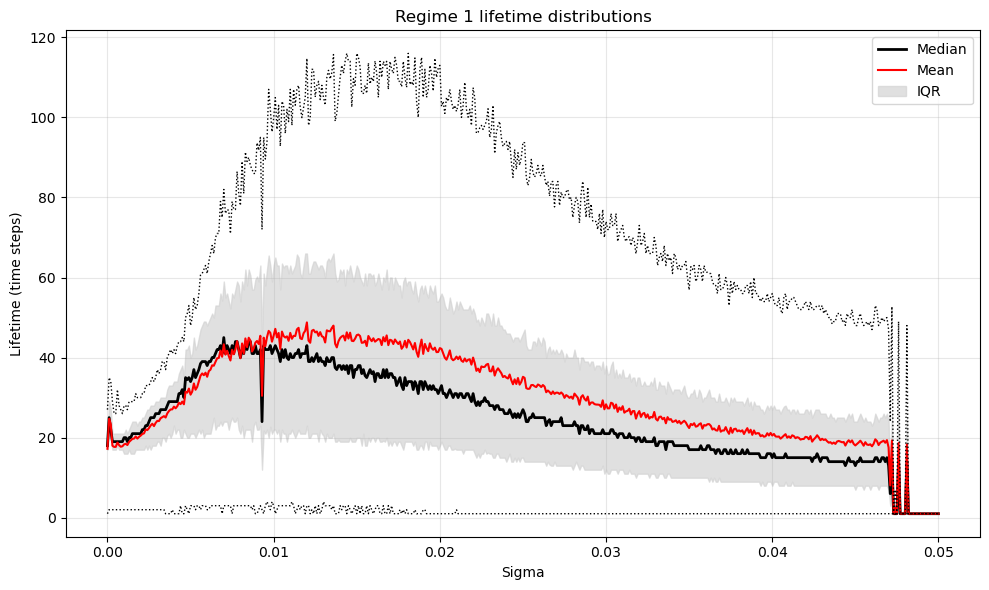

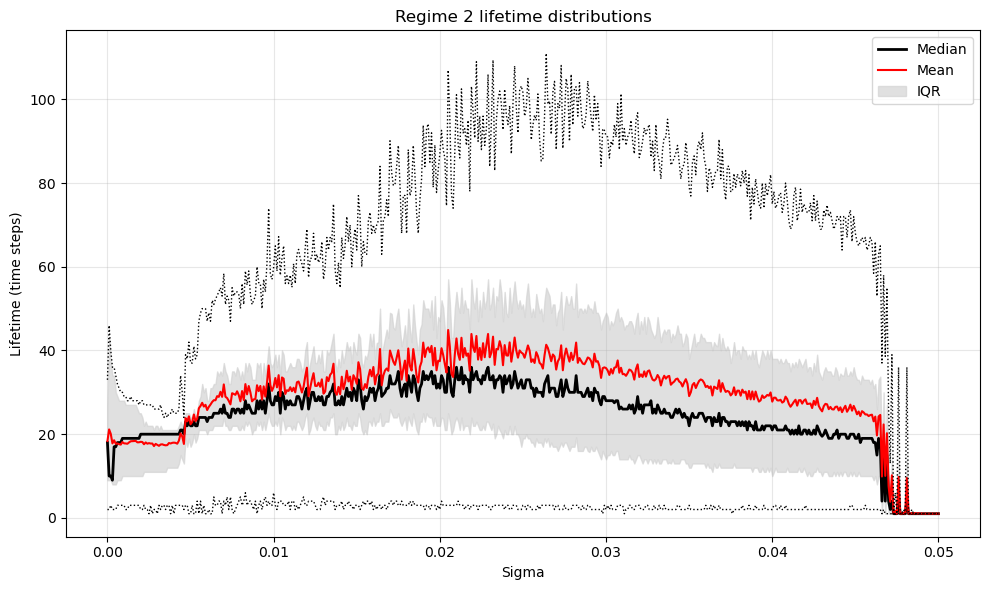

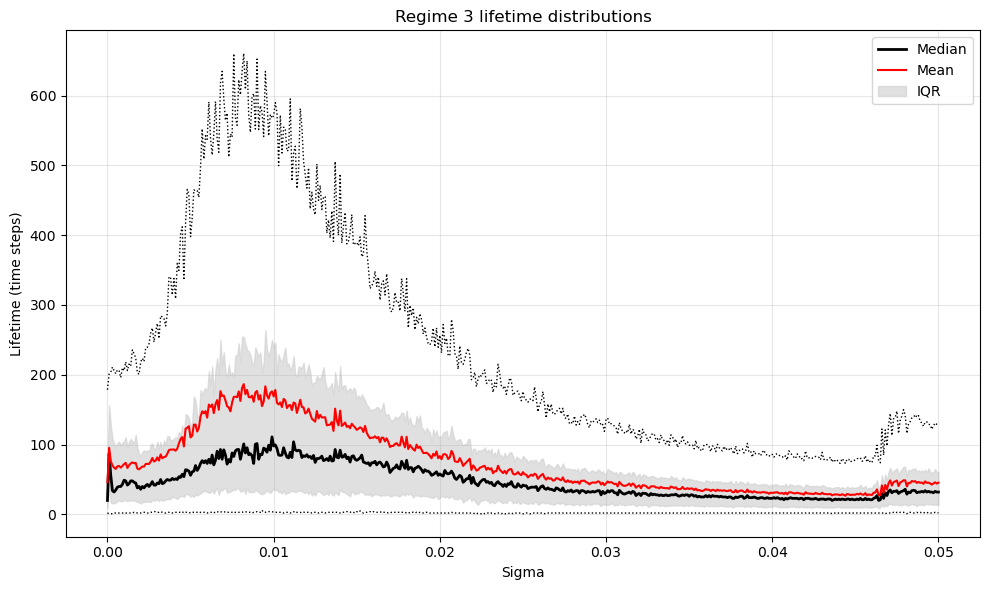

In [4]:
escape_results = collect_escape_results(
    "./cdv_model/data", "*_results.pkl")
for regime in [1, 2, 3]:
    plot_lifetime_distributions_lines(
        escape_results, regime=regime, logx=False)

Results agree up to large values of sigma, which has something to do with the labelling probably. Right now, the labels are assigned to consecutive sigmas based on the minimum distance of the HMM centers.

### For every tenth point

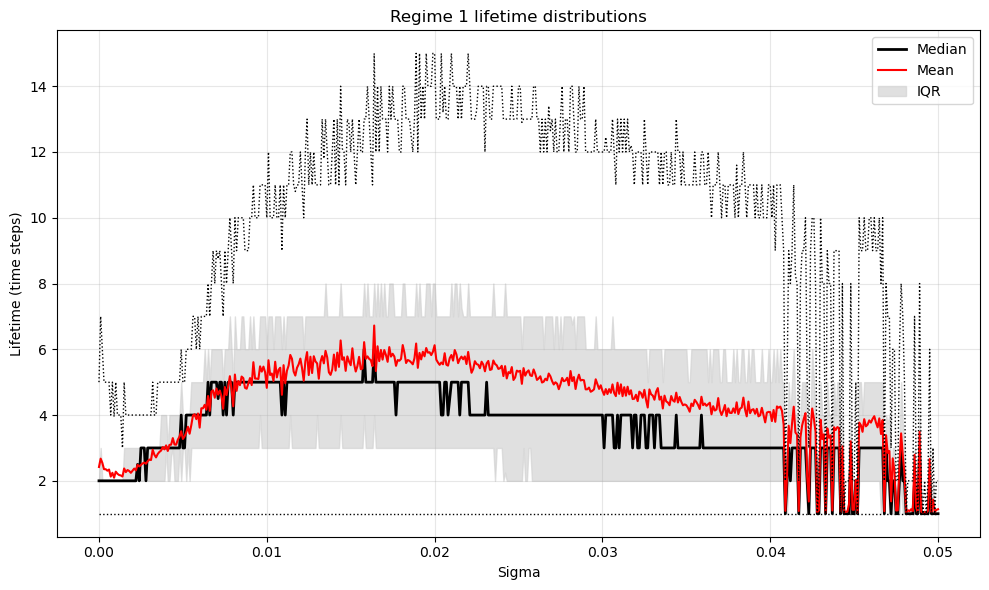

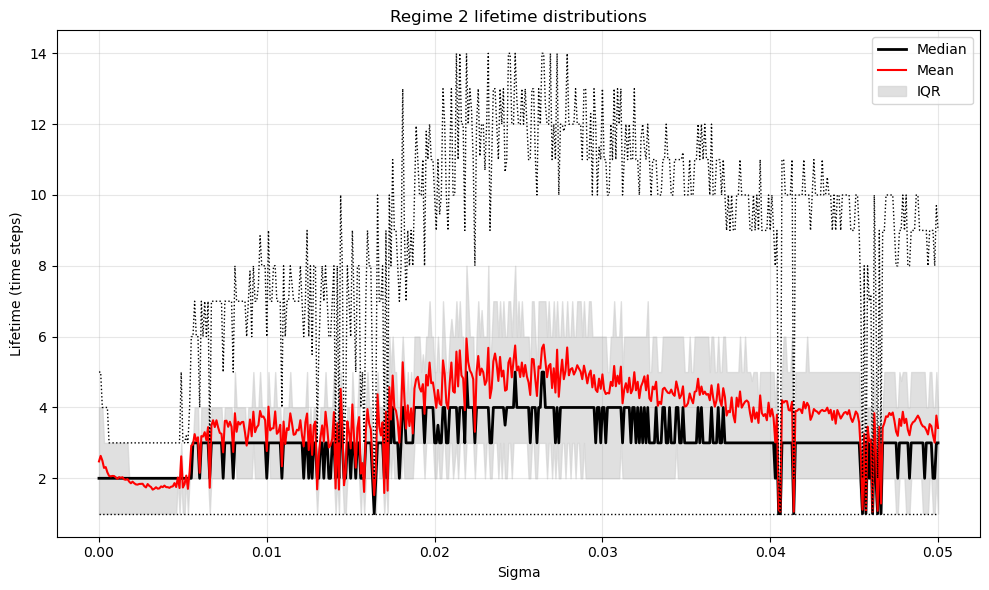

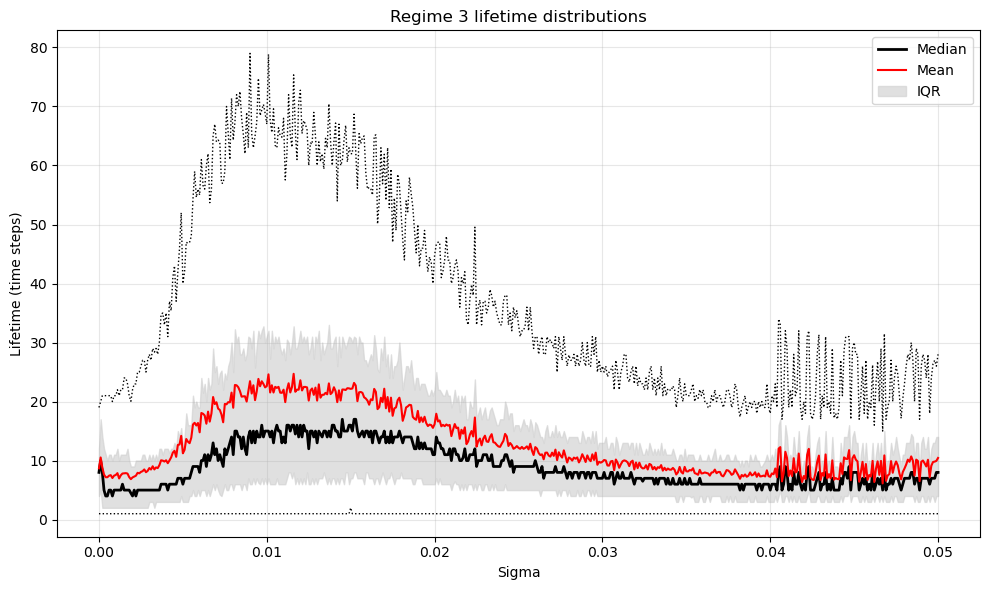

In [5]:
escape_results = collect_escape_results(
    "./cdv_model/data", "*_results_tenth.pkl")
for regime in [1, 2, 3]:
    plot_lifetime_distributions_lines(
        escape_results, regime=regime, logx=False)

Results stay the same, but the y axis is scaled (obviously) and the assignment is noisier

### For the first 10 % of the trajectory

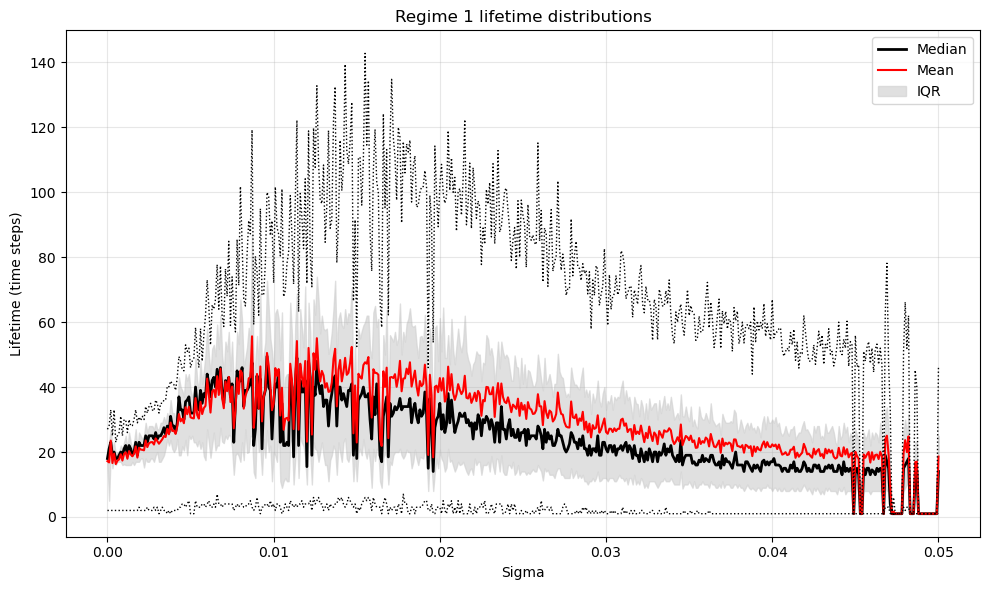

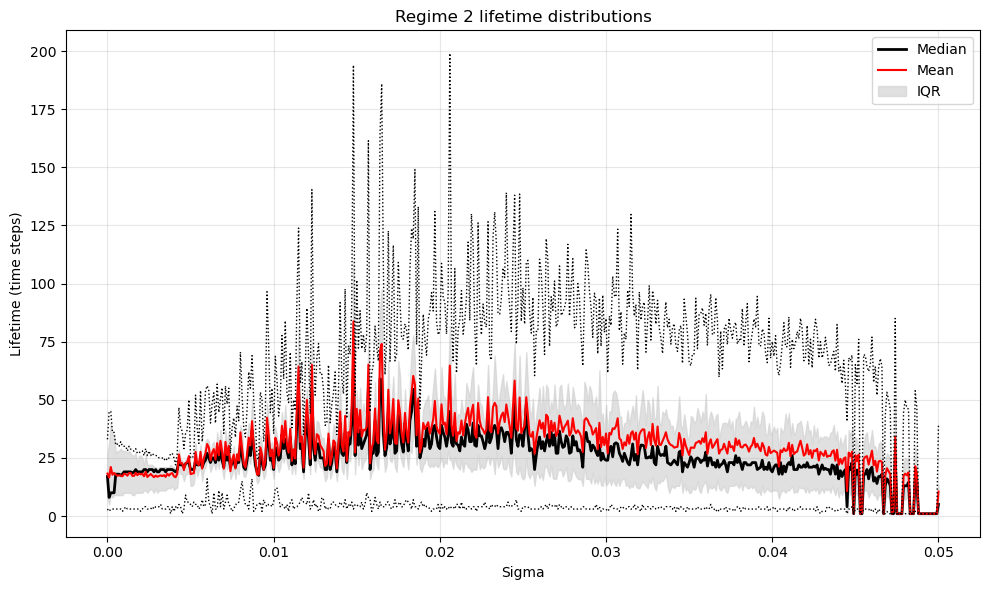

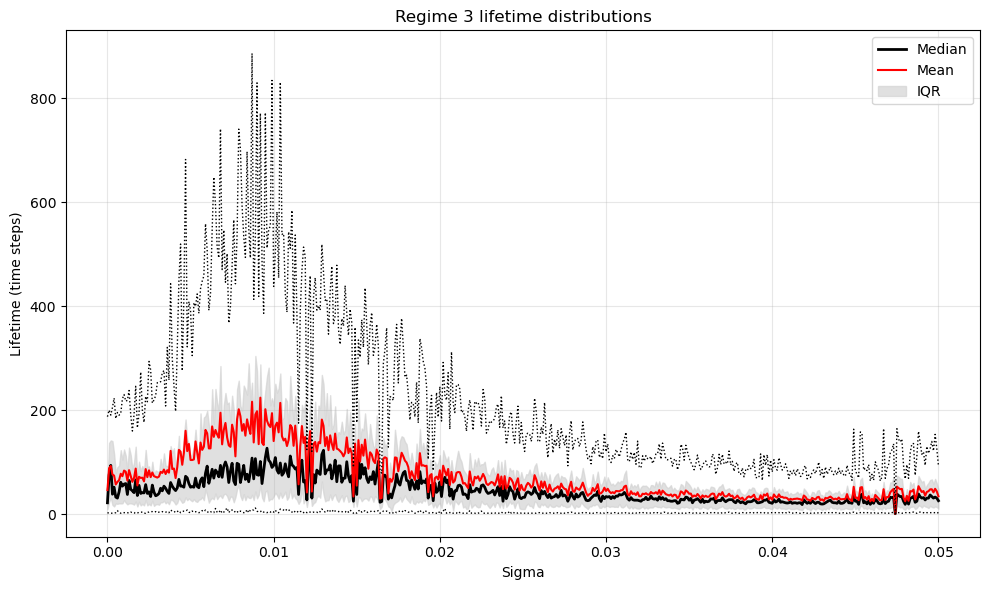

In [6]:
escape_results = collect_escape_results(
    "./cdv_model/data", "*_results_firsttenth.pkl")
for regime in [1, 2, 3]:
    plot_lifetime_distributions_lines(
        escape_results, regime=regime, logx=False)

Results stay the same but the data is noisier. In particular, the sigma, for which stochastic inertia is strongest does not change, but remains at roughly 0.01

## 3. Trajectory-based lifetimes with Diffusion maps regimes

### Regime definition with deterministic trajectory

In [1]:
epsilon = 0.001
subsample_step = 10
n_eig = 12
n_clusters = 2
n_init = 10
eig_indices = [1, 2, 3, 4]   # zero-based eigenvector indices to use
random_state = 0
det_traj = load_d(
    "./cdv_model/data/dataOro20_sigma0p00000000.bin", 6, 200000)[::subsample_step, :]

DMM, A = diffusion_maps_matrix(det_traj, epsilon)

# --- compute clusters from TO ---
det_cluster_res = compute_clusters_from_TO(DMM,
                                           n_eig=n_eig,
                                           n_clusters=n_clusters,
                                           n_init=n_init,
                                           eig_indices=eig_indices,
                                           random_state=random_state)

NameError: name 'load_d' is not defined

In [52]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
PC_scores = pca.fit_transform(det_traj)
fixed_pcs = pca.transform(fixed)
fixed_pcs

array([[ 0.31993984,  0.14062716, -0.09872211],
       [-0.30848029,  0.08339182,  0.05580664]])

/tmp/ipykernel_24200/1467825020.py:9: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
/tmp/ipykernel_24200/1467825020.py:11: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,


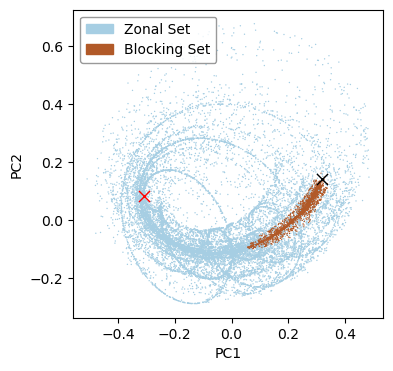

In [53]:
import matplotlib.patches as mpatches
labels = det_cluster_res["labels"].copy()
labels[det_cluster_res["labels"] == 0] = 1
labels[det_cluster_res["labels"] == 1] = 0
plt.figure(figsize=(4, 4))
cmap = plt.get_cmap("Paired", len(np.unique(labels)))
sc = plt.scatter(PC_scores[:, 0], PC_scores[:, 1],
                 c=labels, s=1, linewidth=0, cmap=cmap, label='Clusters')
plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")
plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")

handles = [
    mpatches.Patch(color=cmap(0), label=f'Zonal Set'),
    mpatches.Patch(color=cmap(1), label=f'Blocking Set')
]
plt.legend(
    handles=handles,
    loc='upper left',           # position inside the plot
    frameon=True,
    framealpha=0.8,             # slightly transparent background
    facecolor='white',
    edgecolor='gray'
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig('../../Sets.png', dpi=600)
# plt.tight_layout()
# plt.show()
# cbar = plt.colorbar(sc, ticks=range(len(np.unique(det_cluster_res["labels"]))))
# cbar.set_label('cluster')
# cbar.set_ticklabels(range(len(np.unique(det_cluster_res["labels"]))))

#### For full trajectories

In [ ]:
escape_results = {}  # plain dict
for fname in sorted(glob.glob("./cdv_model/data/dataOro20_sigma*.bin")):
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace("p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)

    sig_data = load_d(fname, 6, 200000)

    # classify
    labels_new = classify_new_trajectory(
        det_traj, det_cluster_res["labels"], sig_data, k=20, threshold=0.5
    )

    esc_dict = calculate_escape_times(labels_new, dt=1.0)

    # insert into dict safely
    for regime, times in esc_dict.items():
        if regime not in escape_results:
            escape_results[regime] = {}
        if sigma_val not in escape_results[regime]:
            escape_results[regime][sigma_val] = []
        escape_results[regime][sigma_val].extend(times)

with open('./cdv_model/data/dataOro20_detReg.pkl', 'wb') as f:
    pickle.dump(escape_results, f)

Processing sigma=0.0
Processing sigma=0.0001
Processing sigma=0.0002
Processing sigma=0.0003
Processing sigma=0.0004
Processing sigma=0.0005
Processing sigma=0.0006
Processing sigma=0.0007
Processing sigma=0.0008
Processing sigma=0.0009
Processing sigma=0.001
Processing sigma=0.0011
Processing sigma=0.0012
Processing sigma=0.0013
Processing sigma=0.0014
Processing sigma=0.0015
Processing sigma=0.0016
Processing sigma=0.0017
Processing sigma=0.0018
Processing sigma=0.0019
Processing sigma=0.002
Processing sigma=0.0021
Processing sigma=0.0022
Processing sigma=0.0023
Processing sigma=0.0024
Processing sigma=0.0025
Processing sigma=0.0026
Processing sigma=0.0027
Processing sigma=0.0028
Processing sigma=0.0029
Processing sigma=0.003
Processing sigma=0.0031
Processing sigma=0.0032
Processing sigma=0.0033
Processing sigma=0.0034
Processing sigma=0.0035
Processing sigma=0.0036
Processing sigma=0.0037
Processing sigma=0.0038
Processing sigma=0.0039
Processing sigma=0.004
Processing sigma=0.0041

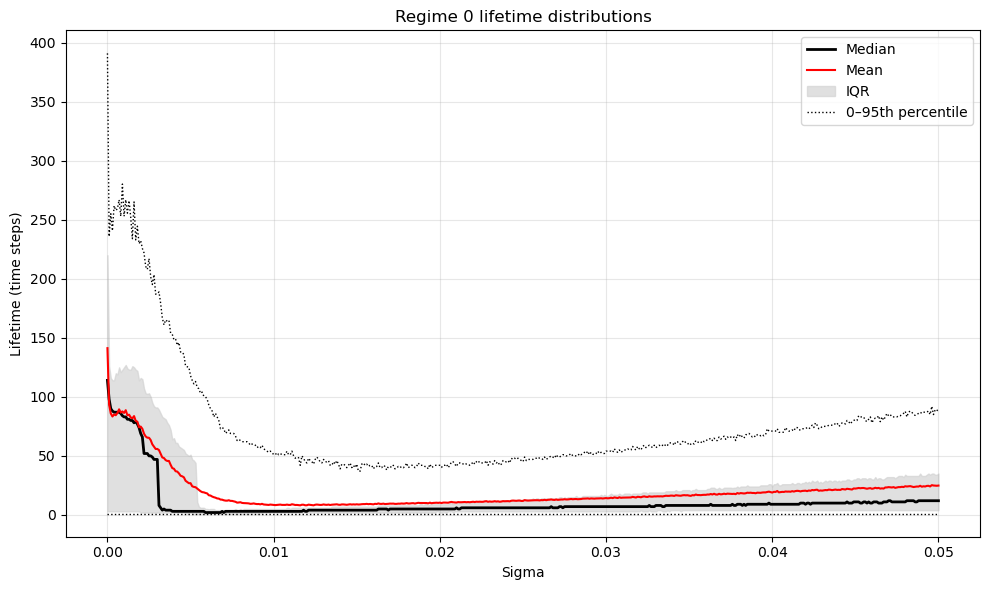

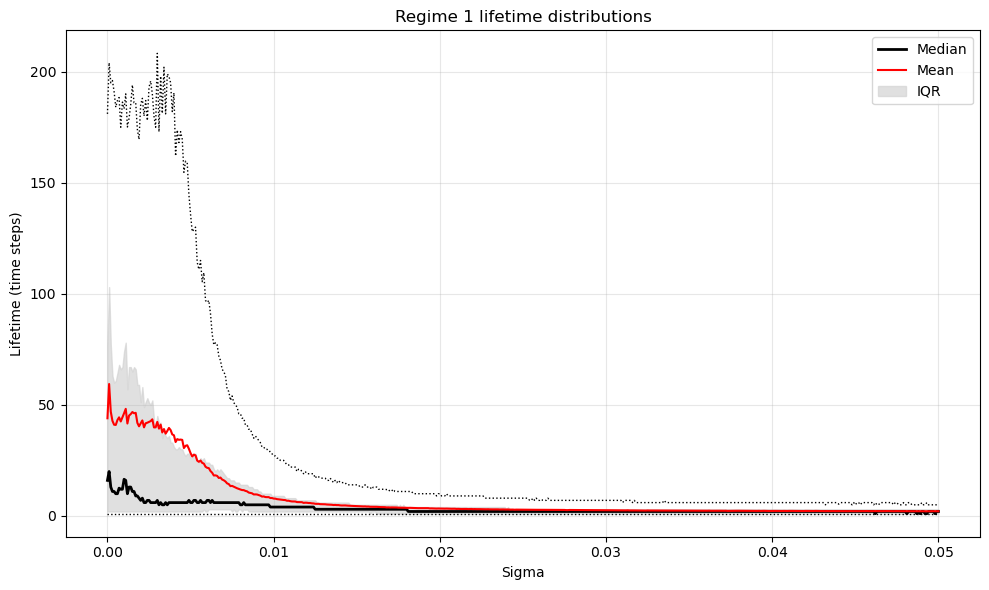

In [9]:
with open('./cdv_model/data/dataOro20_detReg.pkl', 'rb') as f:
    escape_results = pickle.load(f)

for regime in [0, 1]:
    plot_lifetime_distributions_lines(
        escape_results, regime=regime, logx=False)

#### For every tenth point

In [ ]:
# 2min30
escape_results = {}  # plain dict
for fname in sorted(glob.glob("./cdv_model/data/dataOro20_sigma0p*.bin")):
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace("p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)
    print(f"Processing sigma={sigma_val}")

    sig_data = load_d(fname, 6, 200000)[::subsample_step, :]

    # classify
    labels_new = classify_new_trajectory(
        det_traj, det_cluster_res["labels"], sig_data, k=20, threshold=0.5
    )

    esc_dict = calculate_escape_times(labels_new, dt=1.0)

    # insert into dict safely
    for regime, times in esc_dict.items():
        if regime not in escape_results:
            escape_results[regime] = {}
        if sigma_val not in escape_results[regime]:
            escape_results[regime][sigma_val] = []
        escape_results[regime][sigma_val].extend(times)

with open('./cdv_model/data/dataOro20_detRegtenth.pkl', 'wb') as f:
    pickle.dump(escape_results, f)

Processing sigma=0.0
Processing sigma=0.0001
Processing sigma=0.0002
Processing sigma=0.0003
Processing sigma=0.0004
Processing sigma=0.0005
Processing sigma=0.0006
Processing sigma=0.0007
Processing sigma=0.0008
Processing sigma=0.0009
Processing sigma=0.001
Processing sigma=0.0011
Processing sigma=0.0012
Processing sigma=0.0013
Processing sigma=0.0014
Processing sigma=0.0015
Processing sigma=0.0016
Processing sigma=0.0017
Processing sigma=0.0018
Processing sigma=0.0019
Processing sigma=0.002
Processing sigma=0.0021
Processing sigma=0.0022
Processing sigma=0.0023
Processing sigma=0.0024
Processing sigma=0.0025
Processing sigma=0.0026
Processing sigma=0.0027
Processing sigma=0.0028
Processing sigma=0.0029
Processing sigma=0.003
Processing sigma=0.0031
Processing sigma=0.0032
Processing sigma=0.0033
Processing sigma=0.0034
Processing sigma=0.0035
Processing sigma=0.0036
Processing sigma=0.0037
Processing sigma=0.0038
Processing sigma=0.0039
Processing sigma=0.004
Processing sigma=0.0041

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_19048/345183925.py:4: SyntaxWarning: invalid escape sequence '\s'
  escape_results, regime=0, logx=False, xlabel="Noise Strength $\sigma$")


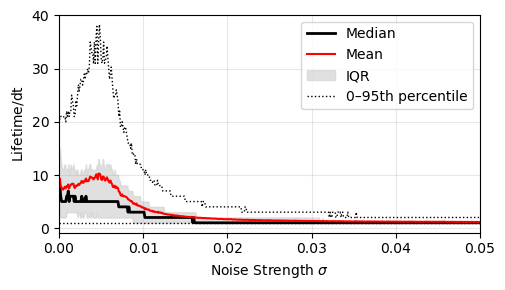

In [75]:
with open('./cdv_model/data/dataOro20_detRegtenth.pkl', 'rb') as f:
    escape_results = pickle.load(f)
fig, ax = plot_lifetime_distributions_lines(
    escape_results, regime=0, logx=False, xlabel="Noise Strength $\sigma$")
ax.set_xlim(0, 0.05)
plt.savefig('../../EscapeTimesTraj.png', dpi=600)

Apparently, stochastic inertia becomes more visible when the stochastic trajectories are downsampled just as the deterministic one is upon regime specification.

### Regime definition with stochastic trajectory

In [ ]:
stoch_traj = load_d(
    "./cdv_model/data/dataOro20_sigma" +
    f"{epsilon:.8f}".replace(".", "p") + ".bin", 6, 200000)[::subsample_step, :]

In [88]:
for eps in np.linspace(0.05, 50, 10):
    DMM, A = diffusion_maps_matrix(stoch_traj, eps)

    # --- compute clusters from TO ---
    stoch_cluster_res = compute_clusters_from_TO(
        DMM,
        n_eig=n_eig,
        n_clusters=n_clusters,
        n_init=n_init,
        eig_indices=eig_indices,
        random_state=random_state
    )
    print(f"Epsilon: {eps}, Cluster sizes: ",
          np.bincount(stoch_cluster_res["labels"]))

Epsilon: 0.05, Cluster sizes:  [18532  1468]
Epsilon: 5.6000000000000005, Cluster sizes:  [ 2317 17683]
Epsilon: 11.150000000000002, Cluster sizes:  [17705  2295]
Epsilon: 16.700000000000003, Cluster sizes:  [17709  2291]
Epsilon: 22.250000000000004, Cluster sizes:  [17707  2293]
Epsilon: 27.800000000000004, Cluster sizes:  [ 2295 17705]
Epsilon: 33.35, Cluster sizes:  [ 2295 17705]
Epsilon: 38.900000000000006, Cluster sizes:  [17705  2295]
Epsilon: 44.45, Cluster sizes:  [17704  2296]
Epsilon: 50.0, Cluster sizes:  [ 2296 17704]


In [86]:
(stoch_cluster_res["labels"] == 0).sum()

np.int64(17281)

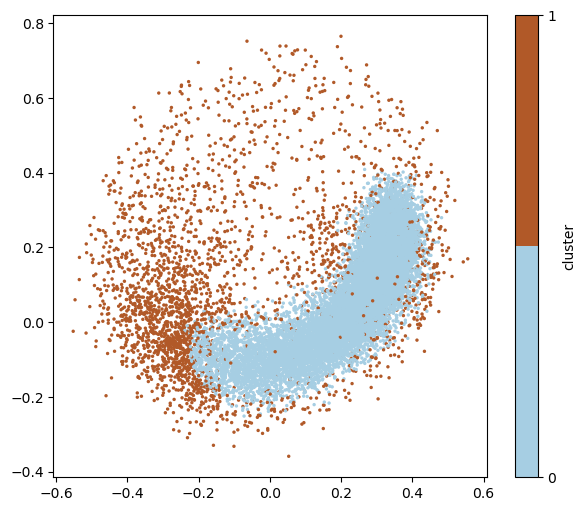

In [87]:
PC_scores = pca.transform(stoch_traj)

plt.figure(figsize=(7, 6))
cmap = plt.get_cmap("Paired", len(np.unique(stoch_cluster_res["labels"])))
sc = plt.scatter(PC_scores[:, 0], PC_scores[:, 1],
                 c=stoch_cluster_res["labels"], s=6, linewidth=0, cmap=cmap)
cbar = plt.colorbar(sc, ticks=range(
    len(np.unique(stoch_cluster_res["labels"]))))
cbar.set_label('cluster')
cbar.set_ticklabels(range(len(np.unique(stoch_cluster_res["labels"]))))

#### Full trajectory

In [ ]:
escape_results = {}  # plain dict
for fname in sorted(glob.glob("./cdv_model/data/dataOro20_sigma*.bin")):
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace("p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)

    # load data (downsampled by 10)
    sig_data = load_d(fname, 6, 200000)

    # classify
    labels_new = classify_new_trajectory(
        stoch_traj, stoch_cluster_res["labels"], sig_data, k=20, threshold=0.5
    )

    esc_dict = calculate_escape_times(labels_new, dt=1.0)

    # insert into dict safely
    for regime, times in esc_dict.items():
        if regime not in escape_results:
            escape_results[regime] = {}
        if sigma_val not in escape_results[regime]:
            escape_results[regime][sigma_val] = []
        escape_results[regime][sigma_val].extend(times)

with open('./cdv_model/data/dataOro20_stochReg.pkl', 'wb') as f:
    pickle.dump(escape_results, f)

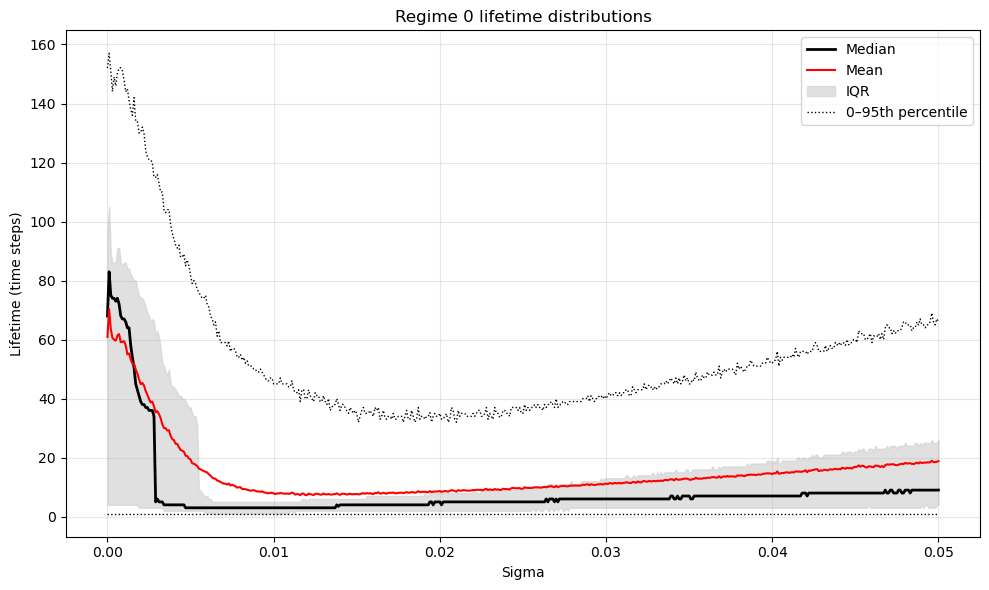

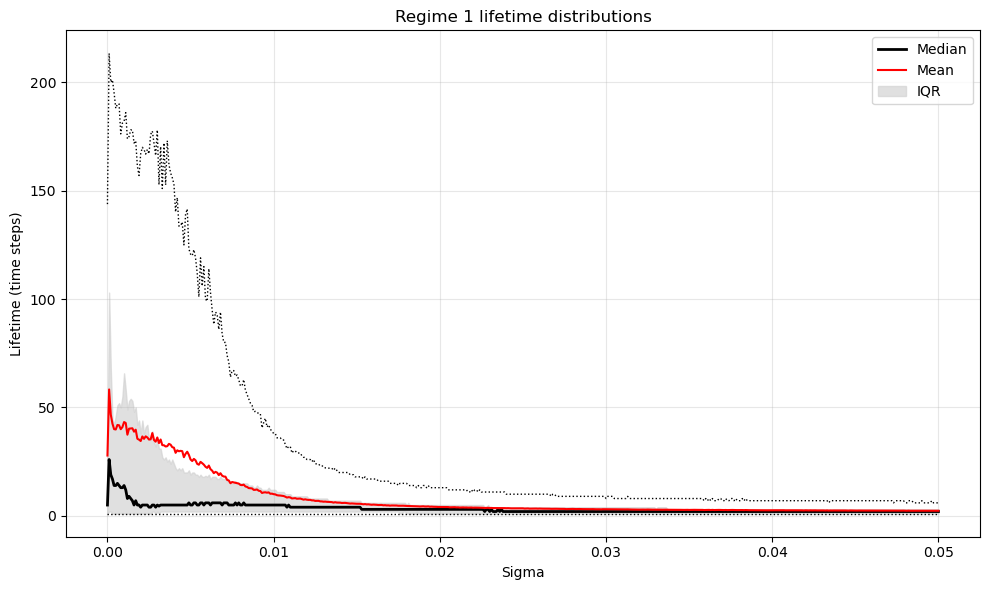

In [15]:
with open('./cdv_model/data/dataOro20_stochReg.pkl', 'rb') as f:
    escape_results = pickle.load(f)

for regime in [0, 1]:
    plot_lifetime_distributions_lines(
        escape_results, regime=regime, logx=False)

#### Every tenth point

In [ ]:
escape_results = {}  # plain dict
for fname in sorted(glob.glob("./cdv_model/data/dataOro20_sigma*.bin")):
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace("p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)

    # load data (downsampled by 10)
    sig_data = load_d(fname, 6, 200000)[::subsample_step, :]

    # classify
    labels_new = classify_new_trajectory(
        stoch_traj, stoch_cluster_res["labels"], sig_data, k=20, threshold=0.5
    )

    esc_dict = calculate_escape_times(labels_new, dt=1.0)

    # insert into dict safely
    for regime, times in esc_dict.items():
        if regime not in escape_results:
            escape_results[regime] = {}
        if sigma_val not in escape_results[regime]:
            escape_results[regime][sigma_val] = []
        escape_results[regime][sigma_val].extend(times)

with open('./cdv_model/data/dataOro20_stochRegtenth.pkl', 'wb') as f:
    pickle.dump(escape_results, f)

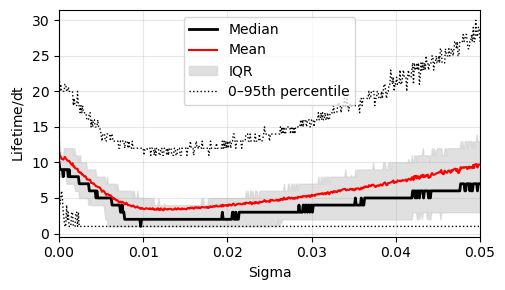

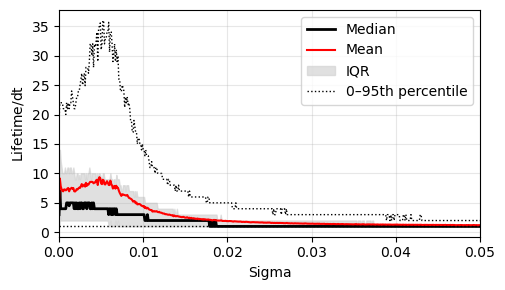

In [10]:
with open('./cdv_model/data/dataOro20_stochRegtenth.pkl', 'rb') as f:
    escape_results = pickle.load(f)
for regime in [0, 1]:
    plot_lifetime_distributions_lines(
        escape_results, regime=regime, logx=False)
    plt.gca().set_xlim(0, 0.05)

### What if we cluster for every sigma anew?

In [22]:
file_paths = sorted(glob.glob(os.path.join(
    "./cdv_model/data", "*_DMMresults_tenth.pkl")))

# parse sigma values from filenames
sigma_re = re.compile(r"sigma([0-9p\.]+)_DMMresults.*\.pkl$")
files = []
for fp in file_paths:
    m = sigma_re.search(os.path.basename(fp))
    if m:
        sigma_str = m.group(1).replace("p", ".")
        sigma_val = float(sigma_str)
        files.append((sigma_val, fp))
files.sort(key=lambda x: x[0])

# load all results
data_all = {}
for sigma, fp in files:
    with open(fp, "rb") as f:
        d = pickle.load(f)

    data_all[sigma] = d

In [26]:

with open('./cdv_model/data/dataOro20_stochDMMtenth.pkl', 'wb') as f:
    pickle.dump(data_all, f)

In [42]:
data_all[0]["labels"]

array([1, 1, 1, ..., 1, 1, 1], shape=(20000,), dtype=int32)

In [58]:
escape_results = {
    regime: {
        sigma: d["escape_times"][regime]
        for sigma, d in data_all.items() if sigma < 0.01
    }
    for regime in (0, 1)
}

(0.0, 0.05)

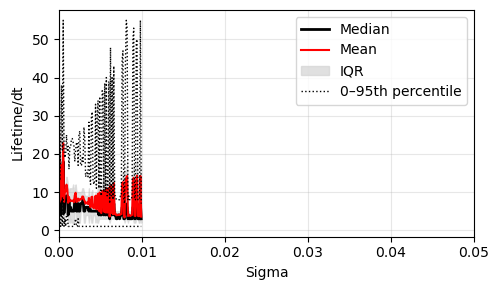

In [60]:
plot_lifetime_distributions_lines(
    escape_results, regime=1, logx=False)
plt.gca().set_xlim(0, 0.05)

In [47]:
sigmas[np.array([0, 3])]

TypeError: only integer scalar arrays can be converted to a scalar index

In [44]:
np.linspace(0, len(sigmas)-1, 25).astype(int)

array([  0,  20,  41,  62,  83, 104, 125, 145, 166, 187, 208, 229, 250,
       270, 291, 312, 333, 354, 375, 395, 416, 437, 458, 479, 500])

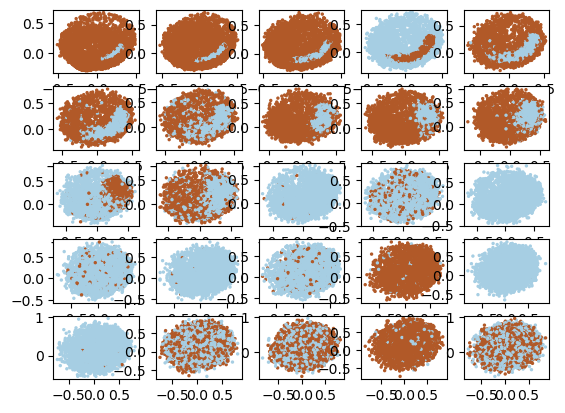

In [54]:
fig, ax = plt.subplots(5, 5)
sigmas = np.array(sorted(data_all.keys()))
sigmas_select = sigmas[np.linspace(0, len(sigmas)-1, 25).astype(int)]
for i, ax_i in enumerate(ax.flatten()):
    sigma = sigmas_select[i]
    stoch_traj = load_d(
        "./cdv_model/data/dataOro20_sigma" +
        f"{sigma:.8f}".replace(".", "p") + ".bin", 6, 200000)[::subsample_step, :]
    PC_scores = pca.transform(stoch_traj)

    cmap = plt.get_cmap("Paired", 2)
    ax_i.scatter(PC_scores[:, 0], PC_scores[:, 1],
                 c=data_all[sigma]["labels"], s=6, linewidth=0, cmap=cmap)

## 4. TO based escape times

Let $L_{\epsilon}$ encode one deterministic step plus diffusion, so $L_{i,j}$ is the probability of moving from state $i$ to state $j$.
Given a regime (blocking set) $B\subset{1,\dots,n-1}$, define the restricted transition submatrix $Q=L_{BB}$. Then the expected time to exit $B$ is recursively defined as $$t = 1 + Q t$$ which yields $$(\mathbf{I} - \mathbf{Q}) \mathbf{t} = \mathbf{1}$$

### With deterministic trajectory

In [19]:
# get entry points
entries = np.where(
    (det_cluster_res["labels"][:-1] == 1) & (det_cluster_res["labels"][1:] == 0))[0]+1
indices_in_reduced = np.nonzero(det_cluster_res["labels"] == 0)[0].searchsorted(
    entries[np.isin(entries, np.nonzero(det_cluster_res["labels"] == 0)[0])])

In [ ]:
# 41 min
t_escape_dict = {}
for sig in np.linspace(0, 0.05, 501):
    eps = 2 * sig**2
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator
    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')

    # Compute expected escape times for the blocking set
    t_escape = expected_escape_times_from_TO(L, det_cluster_res["labels"] == 0)

    # Store
    t_escape_dict[eps] = t_escape

with open('./cdv_model/data/dataOro20_detTOesc.pkl', 'wb') as f:
    pickle.dump(t_escape_dict, f)

Processing epsilon = 0.000000
Processing epsilon = 0.000000
Processing epsilon = 0.000000
Processing epsilon = 0.000000
Processing epsilon = 0.000000
Processing epsilon = 0.000000
Processing epsilon = 0.000001
Processing epsilon = 0.000001
Processing epsilon = 0.000001
Processing epsilon = 0.000002
Processing epsilon = 0.000002
Processing epsilon = 0.000002
Processing epsilon = 0.000003
Processing epsilon = 0.000003
Processing epsilon = 0.000004
Processing epsilon = 0.000005
Processing epsilon = 0.000005
Processing epsilon = 0.000006
Processing epsilon = 0.000006
Processing epsilon = 0.000007
Processing epsilon = 0.000008
Processing epsilon = 0.000009
Processing epsilon = 0.000010
Processing epsilon = 0.000011
Processing epsilon = 0.000012
Processing epsilon = 0.000013
Processing epsilon = 0.000014
Processing epsilon = 0.000015
Processing epsilon = 0.000016
Processing epsilon = 0.000017
Processing epsilon = 0.000018
Processing epsilon = 0.000019
Processing epsilon = 0.000020
Processing

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_19048/1571597581.py:4: SyntaxWarning: invalid escape sequence '\s'
  {0: {np.sqrt(k/2): v[indices_in_reduced] for k, v in t_escape_dict.items()}}, regime=0, logx=False, xlabel="Noise Strength $\sigma$")


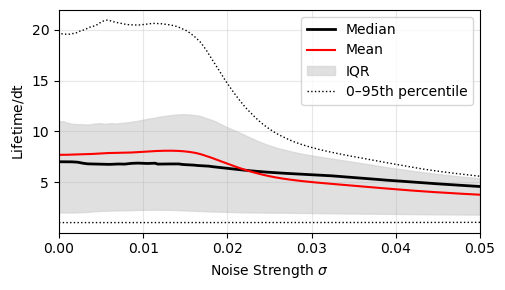

In [109]:
with open('./cdv_model/data/dataOro20_detTOesc.pkl', 'rb') as f:
    t_escape_dict = pickle.load(f)
fig, ax = plot_lifetime_distributions_lines(
    {0: {np.sqrt(k/2): v[indices_in_reduced] for k, v in t_escape_dict.items()}}, regime=0, logx=False, xlabel="Noise Strength $\sigma$")
# fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))
ax.set_xlim(0, 0.05)
plt.savefig('../../EscapeTimesTO.png', dpi=600)

In [ ]:
import numpy as np
from scipy.sparse import eye
from scipy.sparse.linalg import spsolve, spilu, LinearOperator, bicgstab
from scipy.sparse import issparse


def expected_escape_times_from_TO_fast(L, mask,
                                       direct_cutoff=4000,
                                       ilu_drop_tol=1e-3,
                                       krylov_tol=1e-8,
                                       krylov_maxiter_factor=10,
                                       richardson_tol=1e-8,
                                       richardson_maxiter=5000):
    """
    Solve (I - Q) t = 1 where Q = L[indices, :][:, indices] and 'mask' selects the blocking set.

    Strategy:
      - If m <= direct_cutoff: use direct sparse solve (spsolve).
      - Else: try ILU preconditioner + bicgstab.
      - If ILU or bicgstab fails, fallback to simple Richardson iteration:
            t_{k+1} = 1 + Q t_k
        (equivalent to Neumann series) until convergence.

    Parameters:
      L : scipy.sparse matrix (transfer operator)
      mask : boolean array selecting the blocking indices (source nodes)
      direct_cutoff : int, size threshold below which a direct solve is used
      ilu_drop_tol : float, drop tolerance for spilu preconditioner
      krylov_tol : float, tolerance for bicgstab
      krylov_maxiter_factor : int, max iterations = factor * m
      richardson_tol : float, tolerance for Richardson residual
      richardson_maxiter : int, max Richardson iterations

    Returns:
      t_escape : 1D numpy array of length m (floats)
    """
    indices = np.nonzero(mask)[0]
    m = indices.size
    if m == 0:
        return np.array([], dtype=float)

    # Build Q in csr (note: L may be row- or column-stochastic depending on pipeline;
    # this matches your original usage of L[1:,:-1] indexing.)
    Q = L[indices, :][:, indices].tocsr()

    # build I - Q
    IminusQ = eye(m, format='csr') - Q

    # RHS vector
    b = np.ones(m, dtype=float)

    # 1) small problems: direct sparse solver
    if m <= direct_cutoff:
        t = spsolve(IminusQ, b)
        return t

    # 2) try ILU preconditioner + bicgstab
    # spilu requires csc matrix
    try:
        # convert to csc for spilu and compute ILU factorization
        ilu = spilu(IminusQ.tocsc(), drop_tol=ilu_drop_tol)
        # create preconditioner as LinearOperator
        M = LinearOperator((m, m), matvec=ilu.solve)

        maxiter = int(krylov_maxiter_factor * m)
        t, info = bicgstab(IminusQ, b, rtol=krylov_tol, maxiter=maxiter, M=M)
        if info == 0:
            return t
        else:
            # info > 0 means no convergence in maxiter; info < 0 means breakdown
            # proceed to fallback
            print(
                f"bicgstab did not converge (info={info}), falling back to Richardson.")
    except Exception as e:
        # ILU failed (memory/zero pivot etc) -> fallback
        print("ILU preconditioning failed or unavailable, falling back to Richardson. Exception:", e)

    # 3) fallback: Richardson / Neumann fixed-point iteration
    # iterate t_{k+1} = 1 + Q t_k, starting from t0 = 0
    # stop when ||residual||/||b|| < tol, where residual = (I-Q)t - 1
    t = np.zeros(m, dtype=float)
    bnorm = np.linalg.norm(b)
    if bnorm == 0:
        bnorm = 1.0
    for it in range(richardson_maxiter):
        t_new = b + Q.dot(t)
        # compute residual r = (I-Q) t_new - b = -Q(t_new - t)  -> easier compute r = t_new - Q.dot(t_new) - b
        r = t_new - Q.dot(t_new) - b
        res_norm = np.linalg.norm(r)
        if res_norm / bnorm <= richardson_tol:
            return t_new
        t = t_new
    # if still not converged, return last iterate with a warning
    print(
        f"Richardson did not converge in {richardson_maxiter} iterations; residual={res_norm:.3e}")
    return t


t_escape_dict = {}
for sig in np.linspace(0, 0.05, 501):
    eps = 2 * sig**2
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator
    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')

    # Compute expected escape times for the blocking set
    t_escape = expected_escape_times_from_TO(L, det_cluster_res["labels"] == 1)

    # Store
    t_escape_dict[eps] = t_escape

fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Sigma")

### Look at relativ increase

In [26]:
np.asarray(esc[0]).shape

(613,)

In [21]:
t_escape_det[indices_in_reduced].shape

(613,)

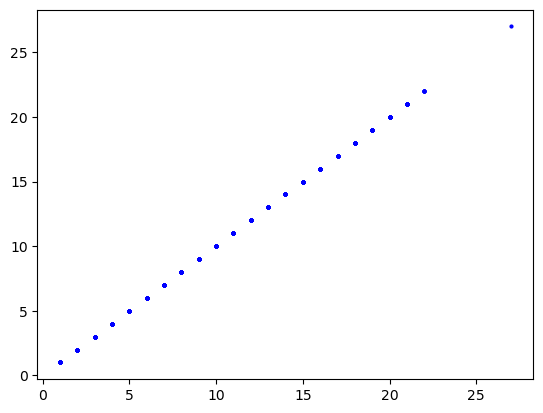

In [27]:
with open('./cdv_model/data/dataOro20_detTOesc.pkl', 'rb') as f:
    t_escape_dict = pickle.load(f)

esc = calculate_escape_times(det_cluster_res["labels"], dt=1)

t_escape_det = t_escape_dict[0]

plt.scatter(np.asarray(esc[0]), t_escape_det[indices_in_reduced],
            s=4, c='blue', label='Deterministic TO')

In [28]:
with open('./cdv_model/data/dataOro20_detTOesc.pkl', 'rb') as f:
    t_escape_dict = pickle.load(f)

t_escape_det = t_escape_dict[0]
epsilons = np.array(sorted(t_escape_dict.keys(), key=float), dtype=float)
# stack arrays in that sorted order
rows = [np.asarray(t_escape_dict[p], dtype=float) for p in epsilons]
M = np.vstack(rows)
argmax_idx = np.argmax(M, axis=0)
best_value = M[argmax_idx, np.arange(M.shape[1])]
best_eps = epsilons[argmax_idx]
rel_increase = best_value / M[0, :]

<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6254/2757870198.py:46: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Deterministic escape time/$\mathrm{dt}$")
/tmp/ipykernel_6254/2757870198.py:58: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label('Maximizing noise strength $\sigma_{\mathrm{max}}$')


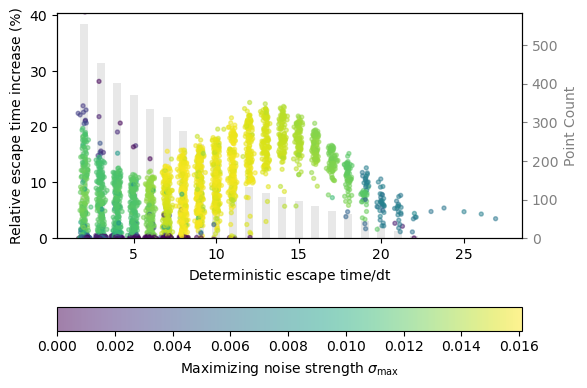

In [36]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4.5))

not_border_points = np.where(t_escape_det != 1)[0]

# --- Histogram (background, secondary y-axis) ---
# Use integer bins so bars align with integer x-values
bin_edges = np.arange(np.min(t_escape_det[not_border_points]),
                      # +2 to include last value
                      np.max(t_escape_det[not_border_points]) + 2)
counts, _ = np.histogram(t_escape_det[not_border_points], bins=bin_edges)

# Compute centers (integers)
bin_centers = bin_edges[:-1] + 0.5

# Create twin axis for counts
ax_hist = ax.twinx()
ax_hist.bar(
    bin_centers-.5, counts, width=.5,
    color='lightgray', alpha=0.5, align='center', zorder=0
)

# Put histogram behind scatter
ax.set_zorder(ax_hist.get_zorder() + 1)
ax.patch.set_visible(False)

# --- Jittered scatter ---
x_jitter_strength = 0.005 * (np.max(t_escape_det[not_border_points]) -
                             np.min(t_escape_det[not_border_points]))
y_jitter_strength = 0.005 * (np.max(rel_increase[not_border_points]) -
                             np.min(rel_increase[not_border_points]))

x_jitter = np.random.normal(0, x_jitter_strength, size=len(not_border_points))
y_jitter = np.random.normal(0, y_jitter_strength, size=len(not_border_points))

sc = ax.scatter(
    t_escape_det[not_border_points] + x_jitter,
    (rel_increase[not_border_points] + y_jitter - 1) * 100,
    c=np.sqrt(best_eps[not_border_points] / 2),
    cmap='viridis', s=8, alpha=0.5, zorder=2
)

# --- Formatting ---
ax.set_xlabel("Deterministic escape time/$\mathrm{dt}$")
ax.set_ylabel("Relative escape time increase (%)")
ax_hist.set_ylabel("Point Count", color="gray")
ax_hist.tick_params(axis='y', colors='gray')

# Match y-axis to data range
y_min = np.min((rel_increase[not_border_points] - 1) * 100)
y_max = np.max((rel_increase[not_border_points] - 1) * 100)
ax.set_ylim(y_min, y_max)

# --- Colorbar at bottom ---
cbar = fig.colorbar(sc, ax=ax, orientation='horizontal', pad=0.2)
cbar.set_label('Maximizing noise strength $\sigma_{\mathrm{max}}$')

# plt.tight_layout()
plt.savefig('../../TOLifetimes_increase.png', dpi=600)
plt.show()

#### Now obtain regime lifetimes

- calculate expected exit times (done above)
- calculate entrance probabilities ("Given an entry into the regime, how likely is it that it came from some point $x_i$)
- take scalar product of both

(see pitch.pdf)

In [ ]:
regime_dict = {}
for eps in np.linspace(0, 0.005, 501):
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')

    # Compute expected escape times for the blocking set
    t_escape = t_escape_dict[eps]
    p0 = np.zeros(len(det_cluster_res["labels"]))
    p0[det_cluster_res["labels"] == 0] = 1 / \
        (det_cluster_res["labels"] == 0).sum()
    p1 = p0 @ L
    p_regime = p1[det_cluster_res["labels"] == 1]
    p_enter = p_regime / p_regime.sum()
    regime_dict[eps] = np.dot(p_enter, t_escape)

with open('./cdv_model/data/dataOro20_TORegdet.pkl', 'wb') as f:
    pickle.dump(regime_dict, f)

Processing epsilon = 0.000010
Processing epsilon = 0.000020
Processing epsilon = 0.000030
Processing epsilon = 0.000040
Processing epsilon = 0.000050
Processing epsilon = 0.000060
Processing epsilon = 0.000070
Processing epsilon = 0.000080
Processing epsilon = 0.000090
Processing epsilon = 0.000100
Processing epsilon = 0.000110
Processing epsilon = 0.000120
Processing epsilon = 0.000130
Processing epsilon = 0.000140
Processing epsilon = 0.000150
Processing epsilon = 0.000160
Processing epsilon = 0.000170
Processing epsilon = 0.000180
Processing epsilon = 0.000190
Processing epsilon = 0.000200
Processing epsilon = 0.000210
Processing epsilon = 0.000220
Processing epsilon = 0.000230
Processing epsilon = 0.000240
Processing epsilon = 0.000250
Processing epsilon = 0.000260
Processing epsilon = 0.000270
Processing epsilon = 0.000280
Processing epsilon = 0.000290
Processing epsilon = 0.000300
Processing epsilon = 0.000310
Processing epsilon = 0.000320
Processing epsilon = 0.000330
Processing

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6254/1013609070.py:15: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")
/tmp/ipykernel_6254/1013609070.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Lifetime/$\mathrm{dt}$")


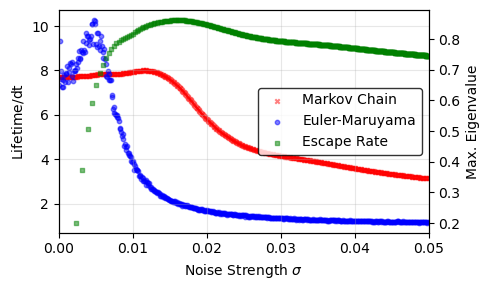

In [40]:
with open('./cdv_model/data/dataOro20_detRegtenth.pkl', 'rb') as f:
    escape_results = pickle.load(f)
means = np.array([np.mean(v) for k, v in sorted(escape_results[0].items())])
with open('./cdv_model/data/dataOro20_TORegdet.pkl', 'rb') as f:
    regime_dict = pickle.load(f)

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.sqrt(np.array(sorted(regime_dict.keys())) / 2),
           np.array([regime_dict[k]
                     for k in sorted(regime_dict.keys())]),
           color='red', marker='x', s=10, alpha=.5, label='Markov Chain')

ax.scatter(np.asarray(sorted(escape_results[0].keys()), dtype=float), means,
           color='blue', s=10, alpha=0.5, label='Euler-Maruyama')
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Lifetime/$\mathrm{dt}$")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.05)

# add the rate
with open('./cdv_model/data/dataOro20_detRate.pkl', 'rb') as f:
    escape_rate_dict = pickle.load(f)

ax_rate = ax.twinx()
ax_rate.scatter(np.sqrt(np.array(sorted(escape_rate_dict.keys()))/2),
                np.array([escape_rate_dict[k]
                          for k in sorted(escape_rate_dict.keys())]),
                color='green', marker='s', s=10, alpha=.5, label='Escape Rate')
ax_rate.set_ylabel("Max. Eigenvalue")
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_rate.get_legend_handles_labels()

# Combine them
handles = handles1 + handles2
labels = labels1 + labels2

# Make a single legend
ax.legend(handles, labels, facecolor='white', edgecolor='black', loc='right')

plt.tight_layout()
plt.savefig('../../RegimeLifetimesEMvsTO.png', dpi=600)

### With stochastic trajectory

In [ ]:
t_escape_dict = {}
for eps in np.linspace(0, 0.005, 501)[1:]:
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(stoch_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator
    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')

    # Compute expected escape times for the blocking set
    t_escape = expected_escape_times_from_TO(
        L, stoch_cluster_res["labels"] == 1)

    # Store
    t_escape_dict[eps] = t_escape

with open('./cdv_model/data/dataOro20_stochTOesc.pkl', 'wb') as f:
    pickle.dump(t_escape_dict, f)

Processing epsilon = 0.000010
Processing epsilon = 0.000020
Processing epsilon = 0.000030
Processing epsilon = 0.000040
Processing epsilon = 0.000050
Processing epsilon = 0.000060
Processing epsilon = 0.000070
Processing epsilon = 0.000080
Processing epsilon = 0.000090
Processing epsilon = 0.000100
Processing epsilon = 0.000110
Processing epsilon = 0.000120
Processing epsilon = 0.000130
Processing epsilon = 0.000140
Processing epsilon = 0.000150
Processing epsilon = 0.000160
Processing epsilon = 0.000170
Processing epsilon = 0.000180
Processing epsilon = 0.000190
Processing epsilon = 0.000200
Processing epsilon = 0.000210
Processing epsilon = 0.000220
Processing epsilon = 0.000230
Processing epsilon = 0.000240
Processing epsilon = 0.000250
Processing epsilon = 0.000260
Processing epsilon = 0.000270
Processing epsilon = 0.000280
Processing epsilon = 0.000290
Processing epsilon = 0.000300
Processing epsilon = 0.000310
Processing epsilon = 0.000320
Processing epsilon = 0.000330
Processing

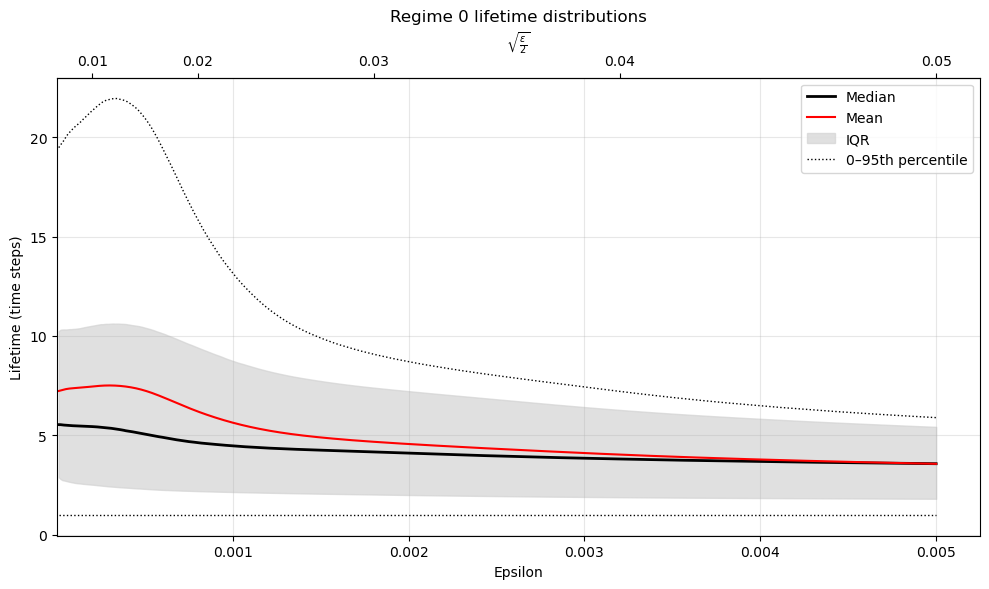

In [46]:
with open('./cdv_model/data/dataOro20_stochTOesc.pkl', 'rb') as f:
    t_escape_dict = pickle.load(f)

fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Epsilon")
fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))

## 5. Escape rates

The maximum Eigenvalue of $Q$ is associated with the escape time via the Perron-Frobenius Theorem. The probability of still being in $B$ after $k$ steps starting in $B$ behaves asymptotically as $$\mathrm{Pr}(X_k \in B) \approx C \lambda_{\max}^k$$. Therefore, $\lambda_{\max}$ measures the persistence time (sth like the inverse escape rate). Roughly, if survival decays geometrically as $\mathrm{Pr}(t > k) \approx \lambda_{\max}^k$, then the mean escape time satisfies $$\mathbb{E}[t] \approx \frac{1}{1-\lambda_{\max}}$$

In [ ]:
from scipy.sparse.linalg import eigs


escape_rate_dict = {}
for eps in np.linspace(0, 0.005, 501)[1:]:
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator and transpose
    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')

    Q = L[det_cluster_res["labels"] == 1, :][:, det_cluster_res["labels"] == 1]
    eigval, _ = eigs(Q, k=1, which='LM')
    # Store
    escape_rate_dict[eps] = eigval.real[0]

with open('./cdv_model/data/dataOro20_detRate.pkl', 'wb') as f:
    pickle.dump(escape_rate_dict, f)

Processing epsilon = 0.000010
Processing epsilon = 0.000020
Processing epsilon = 0.000030
Processing epsilon = 0.000040
Processing epsilon = 0.000050
Processing epsilon = 0.000060
Processing epsilon = 0.000070
Processing epsilon = 0.000080
Processing epsilon = 0.000090
Processing epsilon = 0.000100
Processing epsilon = 0.000110
Processing epsilon = 0.000120
Processing epsilon = 0.000130
Processing epsilon = 0.000140
Processing epsilon = 0.000150
Processing epsilon = 0.000160
Processing epsilon = 0.000170
Processing epsilon = 0.000180
Processing epsilon = 0.000190
Processing epsilon = 0.000200
Processing epsilon = 0.000210
Processing epsilon = 0.000220
Processing epsilon = 0.000230
Processing epsilon = 0.000240
Processing epsilon = 0.000250
Processing epsilon = 0.000260
Processing epsilon = 0.000270
Processing epsilon = 0.000280
Processing epsilon = 0.000290
Processing epsilon = 0.000300
Processing epsilon = 0.000310
Processing epsilon = 0.000320
Processing epsilon = 0.000330
Processing

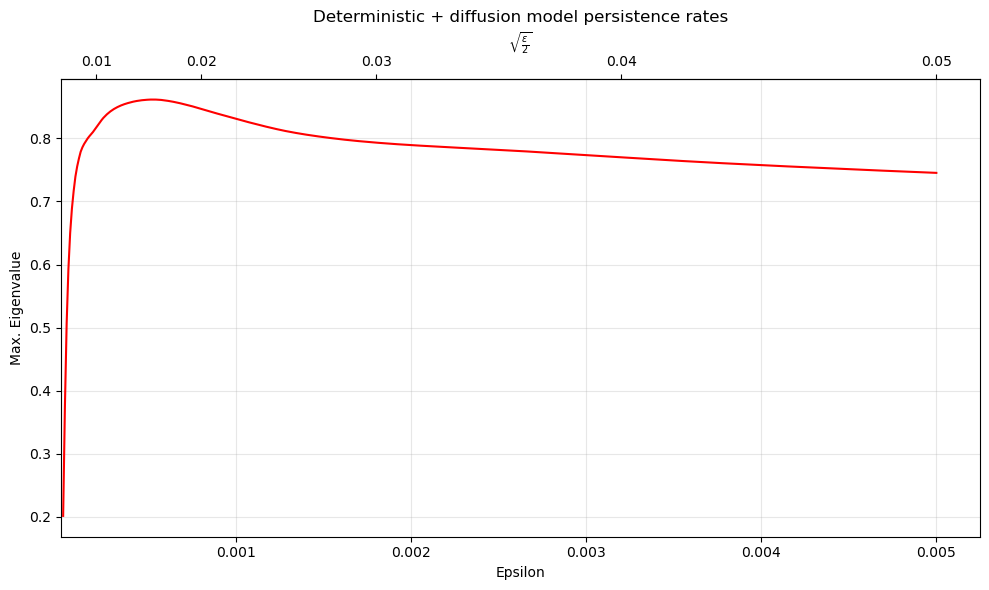

In [47]:
with open('./cdv_model/data/dataOro20_detRate.pkl', 'rb') as f:
    escape_rate_dict = pickle.load(f)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.array(sorted(escape_rate_dict.keys())),
        np.array([escape_rate_dict[k]
                 for k in sorted(escape_rate_dict.keys())]),
        color='red', linewidth=1.5)
ax.set_xlabel("Epsilon")
ax.set_ylabel("Max. Eigenvalue")
ax.set_title("Deterministic + diffusion model persistence rates")
ax.grid(True, alpha=0.3)

fig, ax = add_scaled_top_axis(fig, ax, sorted(escape_rate_dict.keys()))
plt.tight_layout()